## 1. What this notebook computes

The author's metric contains one unknown function, $a_4(x_4)$. Its simplest
choice is the **linear member** $a_4 = AHx_4 + a_0$: 3-space grows like
$e^{AHx_4}$ and the three extra times shrink like $e^{-AHx_4}$ (exponential
deflation for $A > 0$). The field equations then say exactly what source (energy
density $\rho$ and pressure $p$) must be present. This notebook

- reads the Lovelock tensors of the field equations from the Revision record and
  derives from them the required $\kappa\rho$ and $\kappa p$ for every slope $A$,
  cosmological constant $\Lambda$ and Lovelock couplings $\alpha_1, \alpha_2,
  \alpha_3$, and compares them with the record;
- shows that the result does not change when $A$ is replaced by $-A$ (deflation is
  a choice of sign);
- maps, in Einstein gravity, where $\rho$ and $p$ are positive or negative, and
  shows that a positive energy density always comes with $w = p/\rho < -1$;
- shows what the Gauss-Bonnet coupling $\alpha_2$ and the third-order coupling
  $\alpha_3$ change, where the null energy condition holds, and where a vacuum
  (no source at all) exists;
- writes the conditions that a homogeneous condensate of the commuting field
  dirac16complex00 must meet to be the source;
- draws eight teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 12b (The source that the linear member a4 = A H x4 requires) is the file
`Revision/textbook/notebooks/12b_required_source.ipynb` of the repository Dirac_claude.
It reads the Lovelock components of the a4 field equations from the Revision record,
derives the energy density and the pressure that the exponentially deflating linear
member a4 = A H x4 + a0 requires for every slope A, every cosmological constant and every
Lovelock coupling, checks the symmetry A to minus A, the null energy condition, the
Einstein-Gauss-Bonnet and third-order vacua and the conditions on a homogeneous
condensate of dirac16complex00, compares every result with the Revision records, and
draws eight teaching plots. It needs a computer with Windows 11, macOS or Linux, an
internet connection for the installation, the program Git, and Python 3.12 or newer (the
notebooks were built with Python 3.14.5) with these packages at exactly these versions:
numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat
5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself
imports numpy, sympy and matplotlib; the other packages run Jupyter, the program that
shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 12b_required_source.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 12b_required_source.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
12b_required_source.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/12b.captions.json`
- `Revision/textbook/figures/12b_1_einstein_source.png`
- `Revision/textbook/figures/12b_2_source_regions.png`
- `Revision/textbook/figures/12b_3_phantom_w.png`
- `Revision/textbook/figures/12b_4_gauss_bonnet_source.png`
- `Revision/textbook/figures/12b_5_null_energy_map.png`
- `Revision/textbook/figures/12b_6_gauss_bonnet_vacuum.png`
- `Revision/textbook/figures/12b_7_third_order_vacua.png`
- `Revision/textbook/figures/12b_8_condensate_slope.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all eight figure files exist
    ALL 24 CHECKS PASSED (notebook 12b)

and the notebook must show 8 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/12b_required_source.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" naming a4-equations.json: the notebook reads the Revision record of
  the repository. Run it inside the folder Revision/textbook/notebooks of a complete copy
  of the repository made with git clone, not on a copy of the notebook file alone.
- "Jupyter command `jupyter-nbconvert` not found" or "Jupyter command `jupyter-lab` not
  found" after typing `python -m jupyter`: the program jupyter starts its parts nbconvert
  and lab as separate programs, which it looks for in the folders of the search path
  PATH, and the folder that holds them is not on it. Start the two parts as Python
  modules instead, with the environment active (Step 4) and in the folder
  Revision/textbook/notebooks (Step 5): the first command below opens the notebook in
  JupyterLab, the second runs it headless

      python -m jupyterlab 12b_required_source.ipynb
      python -m nbconvert --to notebook --execute --inplace 12b_required_source.ipynb

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 12b (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 12b (The source that the linear member a4 = A H x4 requires) is the file
# Revision/textbook/notebooks/12b_required_source.ipynb of the repository Dirac_claude.
# It reads the Lovelock components of the a4 field equations from the Revision record,
# derives the energy density and the pressure that the exponentially deflating linear
# member a4 = A H x4 + a0 requires for every slope A, every cosmological constant and
# every Lovelock coupling, checks the symmetry A to minus A, the null energy condition,
# the Einstein-Gauss-Bonnet and third-order vacua and the conditions on a homogeneous
# condensate of dirac16complex00, compares every result with the Revision records, and
# draws eight teaching plots. It needs a computer with Windows 11, macOS or Linux, an
# internet connection for the installation, the program Git, and Python 3.12 or newer
# (the notebooks were built with Python 3.14.5) with these packages at exactly these
# versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy, sympy and matplotlib; the other packages run Jupyter,
# the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 12b_required_source.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 12b_required_source.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 12b_required_source.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/12b.captions.json
# - Revision/textbook/figures/12b_1_einstein_source.png
# - Revision/textbook/figures/12b_2_source_regions.png
# - Revision/textbook/figures/12b_3_phantom_w.png
# - Revision/textbook/figures/12b_4_gauss_bonnet_source.png
# - Revision/textbook/figures/12b_5_null_energy_map.png
# - Revision/textbook/figures/12b_6_gauss_bonnet_vacuum.png
# - Revision/textbook/figures/12b_7_third_order_vacua.png
# - Revision/textbook/figures/12b_8_condensate_slope.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all eight figure files exist
#     ALL 24 CHECKS PASSED (notebook 12b)
#
# and the notebook must show 8 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/12b_required_source.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" naming a4-equations.json: the notebook reads the Revision record
#   of the repository. Run it inside the folder Revision/textbook/notebooks of a complete
#   copy of the repository made with git clone, not on a copy of the notebook file alone.
# - "Jupyter command jupyter-nbconvert not found" or "Jupyter command jupyter-lab not
#   found" after typing python -m jupyter: the program jupyter starts its parts nbconvert
#   and lab as separate programs, which it looks for in the folders of the search path
#   PATH, and the folder that holds them is not on it. Start the two parts as Python
#   modules instead, with the environment active (Step 4) and in the folder
#   Revision/textbook/notebooks (Step 5): the first command below opens the notebook in
#   JupyterLab, the second runs it headless
#     python -m jupyterlab 12b_required_source.ipynb
#     python -m nbconvert --to notebook --execute --inplace 12b_required_source.ipynb
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "12b"  # this notebook: chapter 12, example b


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 12b complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Linear member**: the choice $a_4 = AHx_4 + a_0$ with constant **slope** $A$, so
  that $a_4' = AH$ and $a_4'' = 0$. $A > 0$: 3-space inflates and the extra times
  $x_5, x_6, x_7$ deflate exponentially; $A < 0$: the opposite; $A = 0$: static.
- **Source**: the matter whose energy-momentum tensor stands on the right-hand side
  of the field equations: energy density $\rho$, pressures $p_3$ (3-space), $p_t$
  (extra times), $p_8$ (hidden direction $x_8$).
- **Required source**: the $\rho$ and $p$ that the field equations demand for a
  given $a_4$; we read them off the equations instead of assuming a kind of matter.
- **Couplings**: $\alpha_1$ (Einstein), $\alpha_2$ (Gauss-Bonnet), $\alpha_3$ (third
  order); **Einstein gravity** is $\alpha_1 = 1$, $\alpha_2 = \alpha_3 = 0$;
  $\Lambda$ is the cosmological constant, $\kappa > 0$ the strength of gravity.
- **Units**: the plots use $H = 1$ and $\kappa = 1$, so $\kappa\rho$, $\kappa p$
  and $\Lambda$ are in units of $H^2$; $\alpha_2 H^2$ and $\alpha_3 H^4$ are pure
  numbers.
- **Equation of state** $w = p/\rho$.
- **Null energy condition** (NEC) along $x_8$: $\rho + p_8 \ge 0$. Ordinary matter
  satisfies it; a source with $w < -1$ and $\rho > 0$ (called *phantom*) violates
  it.
- **Vacuum**: $\rho = p = 0$, no source at all.
- **Condensate**: a configuration of the field dirac16complex00 that depends only on
  the time $x_4$; $S = \bar\Phi\Phi$ is its scalar density, $m$ the mass, and
  $U = \tfrac{\lambda}{2}S^2$ the self-interaction with strength $\lambda$.
- **Status labels**: PROVED (an exact identity, checked here and in the record),
  ASSUMED (a choice made, not derived), OPEN (not established).

## 4. The physical and mathematical situation

For a source that does not depend on $x_8$ and has no mixed components, the
Einstein-Lovelock field equations of the author's metric reduce to (the Revision
record `a4-equations.json`):

$$\sum_k \alpha_k E_{(k)}{}^{x_4}{}_{x_4} + \Lambda = -\kappa\rho,\qquad
\sum_k \alpha_k E_{(k)}{}^{x_8}{}_{x_8} + \Lambda = \kappa p_8,$$
$$\sum_k \alpha_k E_{(k)}{}^{x_1}{}_{x_1} + \Lambda = \kappa p_3,\qquad
\sum_k \alpha_k E_{(k)}{}^{x_5}{}_{x_5} + \Lambda = \kappa p_t.$$

For the linear member every component depends only on $A$, $H$ and the couplings,
so the required $\rho$ and $p$ are constants. The equations allow ANY $a_4$; what
they fix is the source that this $a_4$ needs. Whether a real field supplies that
source is a separate question (section 9 of this notebook states what is known for
one case).

## 5. The Revision records this notebook reproduces

The next cell defines the helpers that read the Revision records: `read_json`
reads a JSON file of the repository, `record_verdict` finds a check by its name in
a report, and `reproduces` is a check that passes only when this notebook's own
result holds AND the record lists the named check with the verdict PASS; it
collects its two printed lines (PASS and reproduces) in a text buffer and prints
them with one call, so that they always stay together in the output.

In [2]:
import contextlib  # redirect_stdout: send printed lines into a buffer
import io  # StringIO: a text buffer in memory

PY = "Revision/field_equations_a4/reports/python-a4-report.json"  # sympy record
WL = "Revision/field_equations_a4/reports/wolfram-a4-report.json"  # Wolfram record
LEAD = "Revision/lead_checks/reports/einstein-gauss-bonnet-a4.json"  # lead check
EQUATIONS = "Revision/field_equations_a4/a4-equations.json"  # the equations


def read_json(relative):
    """Read a JSON file of the repository (a Revision record)."""
    return json.loads(repository_file(relative).read_text(encoding="utf-8"))


def record_verdict(report_file, name):
    """The verdict of the check name in a report ("PASS"), None if absent."""
    for entry in read_json(report_file)["checks"]:
        if entry["name"] == name:
            return entry["verdict"]
    return None


def reproduces(condition, name, report_file, record_name):
    """A check that also requires the record check record_name to be PASS.  Its
    printed lines (PASS and reproduces) are collected in a text buffer and printed
    by one print call, so that they always stay together in the cell's output."""
    found = record_verdict(report_file, record_name) == "PASS"
    lines = io.StringIO()  # a text buffer
    with contextlib.redirect_stdout(lines):  # print() now writes into the buffer
        check(condition and found, name, record=f"{report_file}, check {record_name}")
    print(lines.getvalue(), end="")  # all lines at once


record = read_json(EQUATIONS)
title = record["title"]  # the title stored in the record
say(f"read {EQUATIONS}: {title}")

read Revision/field_equations_a4/a4-equations.json: Einstein-Lovelock field equations for
    a4[x4] in the primordial metric (Revision/SPEC.md section 5)


## 6. The required source of the linear member

The record stores each Lovelock component as a text in the Wolfram Language
(`ad1` stands for $a_4'$, `ad2` for $a_4''$, `^` for a power). The next cell turns
the four distinct components of $E_{(1)}, E_{(2)}, E_{(3)}$ into sympy expressions,
forms the four left-hand sides, and substitutes the linear member
$a_4' = AH$, $a_4'' = 0$. Then it reads off

$$\kappa\rho = -\Big(\sum_k \alpha_k E_{(k)}{}^{x_4}{}_{x_4} + \Lambda\Big),\qquad
\kappa p_8 = \sum_k \alpha_k E_{(k)}{}^{x_8}{}_{x_8} + \Lambda,$$

and the same for $p_3$ and $p_t$.

In [3]:
import numpy as np  # arrays of numbers for the plots
import sympy as sp  # exact algebra with symbols

H = sp.symbols("H", positive=True)  # the constant H of the metric
A = sp.symbols("A", real=True)  # the slope of the linear member
ad1, ad2 = sp.symbols("ad1 ad2", real=True)  # a4' and a4''
alpha1, alpha2, alpha3 = sp.symbols("alpha1 alpha2 alpha3", real=True)
Lam, kappa = sp.symbols("Lam kappa", real=True)  # Lambda and kappa
NAMES = {"ad1": ad1, "ad2": ad2, "H": H, "AA": A, "alpha1": alpha1,
         "alpha2": alpha2, "alpha3": alpha3, "Lam": Lam, "kappa": kappa}


def parse(text):
    """A Wolfram InputForm text of the record as a sympy expression."""
    return sp.sympify(text.replace("^", "**"), locals=NAMES)


ALPHA = {1: alpha1, 2: alpha2, 3: alpha3}
lovelock = record["lovelockTensors"]
side = {key: sum(ALPHA[k] * parse(lovelock[f"E{k}"][key]["input"]) for k in (1, 2, 3))
        for key in ("x1x1", "x4x4", "x5x5", "x8x8")}  # sum_k alpha_k E_(k)
LINEAR = {ad1: A * H, ad2: 0}  # a4' = A H, a4'' = 0
kappa_rho = sp.expand(-(side["x4x4"] + Lam).subs(LINEAR))
kappa_p3 = sp.expand((side["x1x1"] + Lam).subs(LINEAR))
kappa_pt = sp.expand((side["x5x5"] + Lam).subs(LINEAR))
kappa_p8 = sp.expand((side["x8x8"] + Lam).subs(LINEAR))
say(f"kappa rho = {kappa_rho}")
say(f"kappa p8 = {kappa_p8}")

kappa rho = -360*A**6*H**6*alpha3 - 648*A**4*H**6*alpha3 + 36*A**4*H**4*alpha2 -
    1080*A**2*H**6*alpha3 + 120*A**2*H**4*alpha2 - 3*A**2*H**2*alpha1 - 2520*H**6*alpha3
    + 420*H**4*alpha2 - 21*H**2*alpha1 - Lam
kappa p8 = -72*A**6*H**6*alpha3 - 648*A**4*H**6*alpha3 + 12*A**4*H**4*alpha2 -
    1944*A**2*H**6*alpha3 + 168*A**2*H**4*alpha2 - 3*A**2*H**2*alpha1 + 360*H**6*alpha3 -
    180*H**4*alpha2 + 15*H**2*alpha1 + Lam


The next cell checks four things. (1) The three pressures are equal,
$p_3 = p_t = p_8 =: p$ (for $a_4'' = 0$ the components $E^{x_1}{}_{x_1}$,
$E^{x_5}{}_{x_5}$, $E^{x_8}{}_{x_8}$ coincide). (2) $\kappa\rho$ and $\kappa p$ equal
the linear-member formulas stored in the record. (3) Both contain $A$ only through
$A^2$: replacing $A$ by $-A$ changes nothing, so the equations accept deflating
extra times ($A > 0$) and inflating ones ($A < 0$) on the same footing. (4) The
Einstein part ($\alpha_1$) of $\kappa\rho$ is $-3H^2(A^2 + 7)$, as the lead's
independent check found.

In [4]:
reproduces(sp.expand(kappa_p3 - kappa_p8) == 0 and sp.expand(kappa_pt - kappa_p8) == 0,
           "linear member: p3 = pt = p8 = p", PY, "linear_member_equal_pressures")
kappa_p = kappa_p8  # the common pressure, times kappa
linear_record = record["linearMember"]
same = (sp.expand(kappa * parse(linear_record["rho"]["input"]) - kappa_rho) == 0
        and sp.expand(kappa * parse(linear_record["p"]["input"]) - kappa_p) == 0)
reproduces(same, "kappa rho and kappa p equal the record", PY, "json_linear_member")
check(sp.expand(kappa_rho.subs(A, -A) - kappa_rho) == 0
      and sp.expand(kappa_p.subs(A, -A) - kappa_p) == 0,
      "A -> -A leaves rho and p unchanged: deflation is a choice of sign")
reproduces(sp.expand(sp.diff(kappa_rho, alpha1) + 3 * H ** 2 * (A ** 2 + 7)) == 0,
           "the alpha1 part of kappa rho is -3 H^2 (A^2 + 7)",
           LEAD, "einstein_linear_rho_alpha1")

PASS linear member: p3 = pt = p8 = p
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    linear_member_equal_pressures
PASS kappa rho and kappa p equal the record
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    json_linear_member
PASS A -> -A leaves rho and p unchanged: deflation is a choice of sign
PASS the alpha1 part of kappa rho is -3 H^2 (A^2 + 7)
     reproduces Revision/lead_checks/reports/einstein-gauss-bonnet-a4.json, check
    einstein_linear_rho_alpha1


## 7. Einstein gravity

With $\alpha_1 = 1$, $\alpha_2 = \alpha_3 = 0$:

$$\kappa\rho = -(21 + 3A^2)H^2 - \Lambda,\qquad \kappa p = (15 - 3A^2)H^2 + \Lambda,
\qquad \kappa(\rho + p) = -6(1 + A^2)H^2.$$

The last line is the sum of the first two; it does not contain $\Lambda$ and is
negative for every $A$. The next cell checks these formulas against the record and
prints the numbers for $\Lambda = 0$ and $A = 1$ (units $H = \kappa = 1$):
$\kappa\rho = -24$, $\kappa p = 12$, $w = p/\rho = -1/2$.

In [5]:
EINSTEIN = {alpha1: 1, alpha2: 0, alpha3: 0}
rho_e = sp.expand(kappa_rho.subs(EINSTEIN))  # kappa rho in Einstein gravity
p_e = sp.expand(kappa_p.subs(EINSTEIN))  # kappa p in Einstein gravity
report("Einstein: kappa rho", rho_e)
report("Einstein: kappa p", p_e)
same = (sp.expand(kappa * parse(linear_record["rhoEinstein"]["input"]) - rho_e) == 0
        and sp.expand(kappa * parse(linear_record["pEinstein"]["input"]) - p_e) == 0
        and sp.expand(kappa * parse(linear_record["rhoPlusPEinstein"]["input"])
                      - (rho_e + p_e)) == 0)
reproduces(same and sp.expand(rho_e + p_e + 6 * (1 + A ** 2) * H ** 2) == 0,
           "Einstein: kappa (rho + p) = -6 (1 + A^2) H^2 < 0", PY,
           "json_linear_member")
UNITS = {H: 1, Lam: 0, A: 1}
rho_1, p_1 = rho_e.subs(UNITS), p_e.subs(UNITS)
report("Einstein, Lambda = 0, A = 1: kappa rho", rho_1, "H^2")
report("Einstein, Lambda = 0, A = 1: kappa p", p_1, "H^2")
report("Einstein, Lambda = 0, A = 1: w = p/rho", sp.Rational(p_1, rho_1))
check(rho_1 == -24 and p_1 == 12, "A = 1, Lambda = 0: kappa rho = -24, kappa p = 12")

RESULT Einstein: kappa rho = -3*A**2*H**2 - 21*H**2 - Lam
RESULT Einstein: kappa p = -3*A**2*H**2 + 15*H**2 + Lam
PASS Einstein: kappa (rho + p) = -6 (1 + A^2) H^2 < 0
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    json_linear_member
RESULT Einstein, Lambda = 0, A = 1: kappa rho = -24 H^2
RESULT Einstein, Lambda = 0, A = 1: kappa p = 12 H^2
RESULT Einstein, Lambda = 0, A = 1: w = p/rho = -1/2
PASS A = 1, Lambda = 0: kappa rho = -24, kappa p = 12


The next cell draws $\kappa\rho$ and $\kappa p$ of Einstein gravity with
$\Lambda = 0$ as functions of the slope $A$ from $-3$ to $3$. The right half
($A > 0$, deflating extra times) is the mirror image of the left half ($A < 0$,
inflating extra times). With $\Lambda = 0$ the energy density is negative for every
$A$: it is never above $-21H^2/\kappa$.

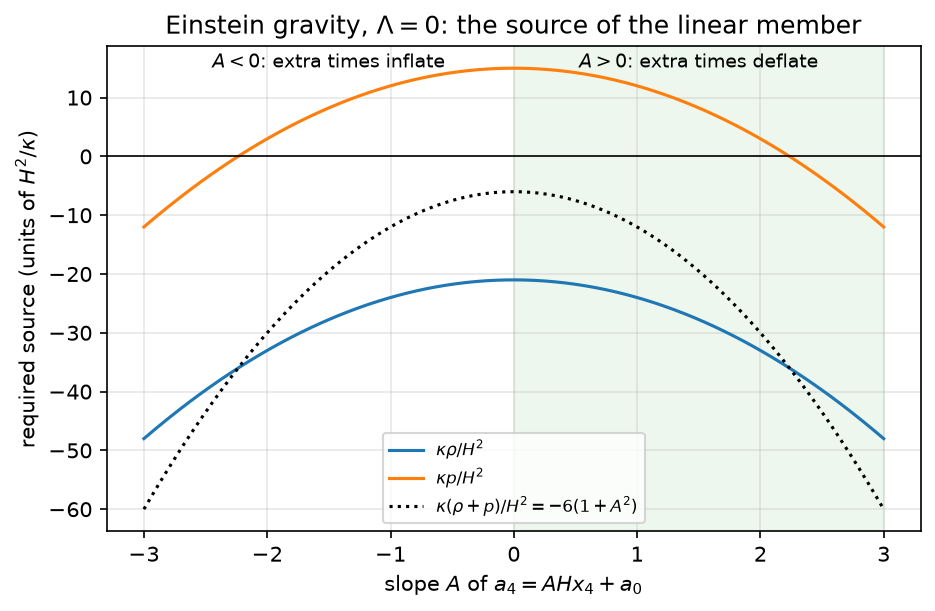

Figure 12b.1 saved as Revision/textbook/figures/12b_1_einstein_source.png


In [6]:
rho_f = sp.lambdify((A, Lam), rho_e.subs(H, 1), "numpy")  # numbers from formulas
p_f = sp.lambdify((A, Lam), p_e.subs(H, 1), "numpy")
a_values = np.linspace(-3.0, 3.0, 301)
fig, ax = plt.subplots()
ax.axvspan(0, 3, color="tab:green", alpha=0.08)  # the deflating half, A > 0
ax.plot(a_values, rho_f(a_values, 0.0), label="$\\kappa\\rho/H^2$")
ax.plot(a_values, p_f(a_values, 0.0), label="$\\kappa p/H^2$")
ax.plot(a_values, rho_f(a_values, 0.0) + p_f(a_values, 0.0), ":", color="black",
        label="$\\kappa(\\rho+p)/H^2=-6(1+A^2)$")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.text(1.5, 15, "$A>0$: extra times deflate", ha="center", fontsize=9)
ax.text(-1.5, 15, "$A<0$: extra times inflate", ha="center", fontsize=9)
ax.set_xlabel("slope $A$ of $a_4 = AHx_4 + a_0$")
ax.set_ylabel("required source (units of $H^2/\\kappa$)")
ax.set_title("Einstein gravity, $\\Lambda = 0$: the source of the linear member")
ax.legend(fontsize=8, loc="lower center")
save_figure(fig, "einstein_source",
            "The source that the linear member $a_4 = AHx_4 + a_0$ requires in "
            "Einstein gravity with $\\Lambda = 0$, as a function of the slope $A$: "
            "$\\kappa\\rho = -(21 + 3A^2)H^2$, $\\kappa p = (15 - 3A^2)H^2$ and their "
            "sum $-6(1 + A^2)H^2$ (dotted), in units of $H^2$. The shaded right half "
            "is the deflating branch $A > 0$; every curve is symmetric under "
            "$A \\to -A$, so the equations do not prefer deflation. The energy "
            "density is negative for every $A$.")

**Where can the energy density be positive?** A cosmological constant shifts
$\kappa\rho$ by $-\Lambda$ and $\kappa p$ by $+\Lambda$. The energy density is
positive when $\Lambda < -(21 + 3A^2)H^2$, and the pressure is positive when
$\Lambda > (3A^2 - 15)H^2$. The two boundary curves never meet (the lower one is
never above $-21H^2$, the upper one never below $-15H^2$), so $\rho$ and $p$ are
never both positive and never both zero. The next cell colours the plane of $A$
and $\Lambda/H^2$ by the signs of $\rho$ and $p$.

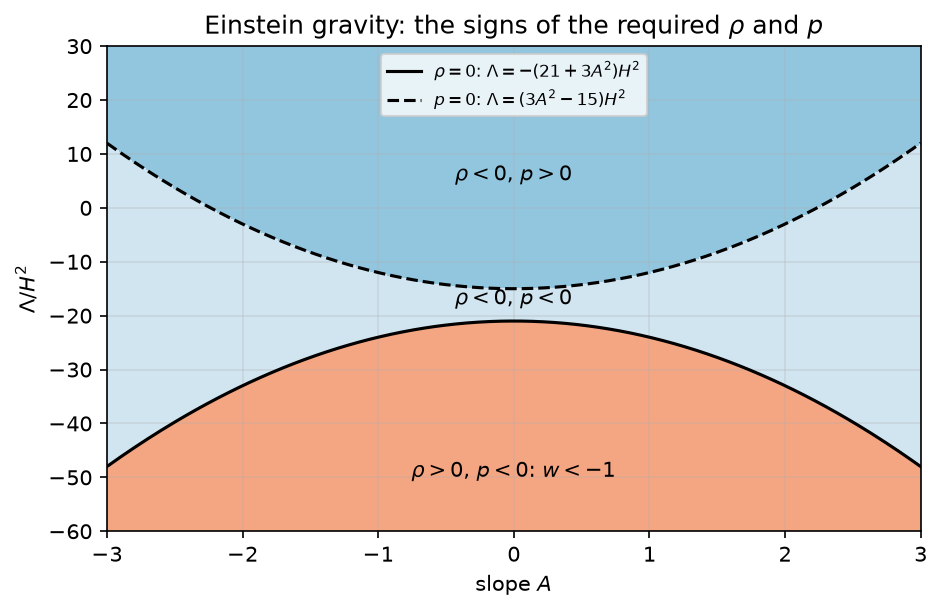

Figure 12b.2 saved as Revision/textbook/figures/12b_2_source_regions.png


In [7]:
a_grid, lam_grid = np.meshgrid(np.linspace(-3, 3, 241), np.linspace(-60, 30, 241))
rho_grid = rho_f(a_grid, lam_grid)
p_grid = p_f(a_grid, lam_grid)
region = np.where(rho_grid > 0, 0, np.where(p_grid < 0, 1, 2))  # three regions
fig, ax = plt.subplots()
colours = matplotlib.colors.ListedColormap(["#f4a582", "#d1e5f0", "#92c5de"])
ax.pcolormesh(a_grid, lam_grid, region, cmap=colours, shading="auto")
ax.plot(a_values, -(21 + 3 * a_values ** 2), color="black",
        label="$\\rho = 0$: $\\Lambda = -(21+3A^2)H^2$")
ax.plot(a_values, 3 * a_values ** 2 - 15, "--", color="black",
        label="$p = 0$: $\\Lambda = (3A^2-15)H^2$")
ax.text(0, -50, "$\\rho > 0$, $p < 0$: $w < -1$", ha="center")
ax.text(0, -18, "$\\rho < 0$, $p < 0$", ha="center")
ax.text(0, 5, "$\\rho < 0$, $p > 0$", ha="center")
ax.set_xlim(-3, 3)
ax.set_ylim(-60, 30)
ax.set_xlabel("slope $A$")
ax.set_ylabel("$\\Lambda/H^2$")
ax.set_title("Einstein gravity: the signs of the required $\\rho$ and $p$")
ax.legend(fontsize=8, loc="upper center")
save_figure(fig, "source_regions",
            "Einstein gravity: the plane of the slope $A$ (horizontal) and the "
            "cosmological constant $\\Lambda/H^2$ (vertical), coloured by the signs "
            "of the energy density $\\rho$ and the pressure $p$ that the linear "
            "member requires. Below the solid curve $\\Lambda = -(21+3A^2)H^2$ the "
            "energy density is positive and the pressure negative, with $w < -1$; "
            "above the dashed curve $\\Lambda = (3A^2-15)H^2$ the pressure is "
            "positive and the energy density negative; in between both are "
            "negative. No point has both positive, and no point is a vacuum.")

**A positive energy density forces $w < -1$.** Because
$\kappa(\rho + p) = -6(1 + A^2)H^2 < 0$, we have $p < -\rho$; dividing by
$\rho > 0$ gives $w = p/\rho < -1$. A source with $\rho > 0$ and $w < -1$ violates
the null energy condition (it is *phantom*). The next cell checks the algebra and
draws $w$ for three values of $\Lambda$, only where $\rho > 0$.

Einstein: w = p/rho = (3*A**2*H**2 - 15*H**2 - Lam)/(3*A**2*H**2 + 21*H**2 + Lam)
PASS w + 1 = (rho + p)/rho, so rho > 0 and rho + p < 0 give w < -1
PASS Lambda = -30 H^2: w < -1 where rho > 0
PASS Lambda = -40 H^2: w < -1 where rho > 0
PASS Lambda = -60 H^2: w < -1 where rho > 0


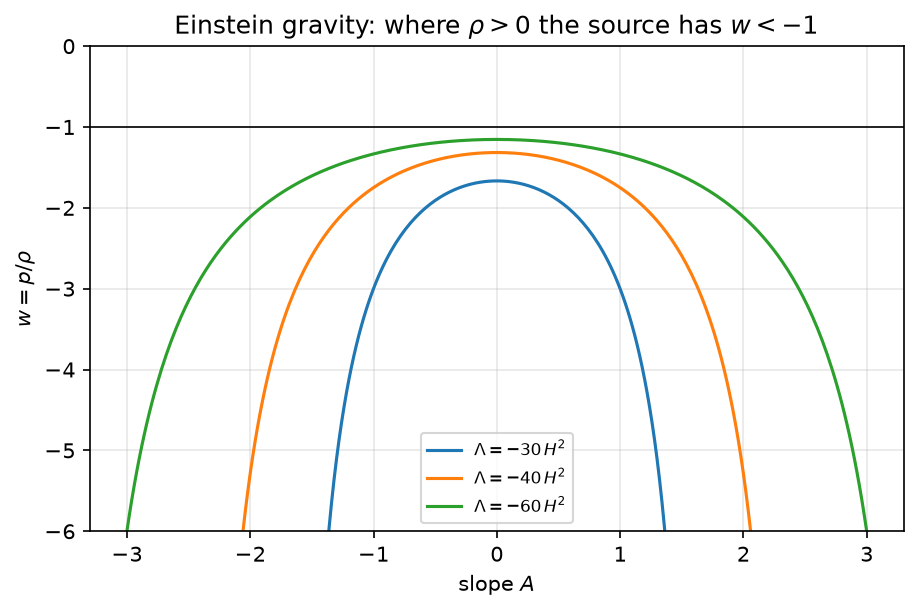

Figure 12b.3 saved as Revision/textbook/figures/12b_3_phantom_w.png


In [8]:
w_e = sp.simplify(p_e / rho_e)  # w = p/rho in Einstein gravity
say(f"Einstein: w = p/rho = {w_e}")
check(sp.simplify(w_e + 1 - (rho_e + p_e) / rho_e) == 0,
      "w + 1 = (rho + p)/rho, so rho > 0 and rho + p < 0 give w < -1")
fig, ax = plt.subplots()
for lam in (-30.0, -40.0, -60.0):
    rho_values = rho_f(a_values, lam)
    keep = rho_values > 1.0  # where the energy density is clearly positive
    w_values = np.where(keep, p_f(a_values, lam) / np.where(keep, rho_values, 1.0),
                        np.nan)  # nan: not drawn
    ax.plot(a_values, w_values, label=f"$\\Lambda = {lam:.0f}\\,H^2$")
    check(np.nanmax(w_values) < -1.0, f"Lambda = {lam:.0f} H^2: w < -1 where rho > 0")
ax.axhline(-1.0, color="black", linewidth=0.8)
ax.set_ylim(-6, 0)
ax.set_xlabel("slope $A$")
ax.set_ylabel("$w = p/\\rho$")
ax.set_title("Einstein gravity: where $\\rho > 0$ the source has $w < -1$")
ax.legend(fontsize=8)
save_figure(fig, "phantom_w",
            "Einstein gravity: the equation of state $w = p/\\rho$ that the linear "
            "member requires, drawn only where the energy density is positive "
            "($\\kappa\\rho > H^2$), for $\\Lambda = -30H^2$, $-40H^2$ and $-60H^2$, "
            "as a function of the slope $A$. Every curve lies below the line "
            "$w = -1$: a positive energy density comes with $w < -1$, because "
            "$\\kappa(\\rho + p) = -6(1 + A^2)H^2$ is negative for every $A$.")

## 8. The Gauss-Bonnet and the third-order couplings

The coupling $\alpha_2$ multiplies the Gauss-Bonnet tensor $E_{(2)}$. The next
cell extracts the $\alpha_2$ parts of $\kappa\rho$ and $\kappa p$ (the derivatives
with respect to $\alpha_2$) and compares them with the lead's independent
computation from the classical Gauss-Bonnet formula:
$H^4(36A^4 + 120A^2 + 420)$ and $12H^4(A^4 + 14A^2 - 15)$. Then it draws
$\kappa\rho$ and $\kappa p$ for Einstein-Gauss-Bonnet gravity
($\alpha_1 = 1$, $\alpha_3 = 0$, $\Lambda = 0$) for four values of $\alpha_2H^2$,
and checks two facts that the plot shows: at $A = 0$ the energy density is
$\kappa\rho = -21H^2 + 420\alpha_2H^4$ (positive only for $\alpha_2H^2 > 1/20$),
and at $A = \pm 1$ the $\alpha_2$ part of the pressure,
$12H^4(1 + 14 - 15) = 0$, vanishes, so $\kappa p = (15 - 3)H^2 = 12H^2$ for every
$\alpha_2$.

PASS the alpha2 part of kappa rho is H^4 (36 A^4 + 120 A^2 + 420)
     reproduces Revision/lead_checks/reports/einstein-gauss-bonnet-a4.json, check
    gauss_bonnet_rho_alpha2
PASS the alpha2 part of kappa p is 12 H^4 (A^4 + 14 A^2 - 15)
     reproduces Revision/lead_checks/reports/einstein-gauss-bonnet-a4.json, check
    gauss_bonnet_p_alpha2


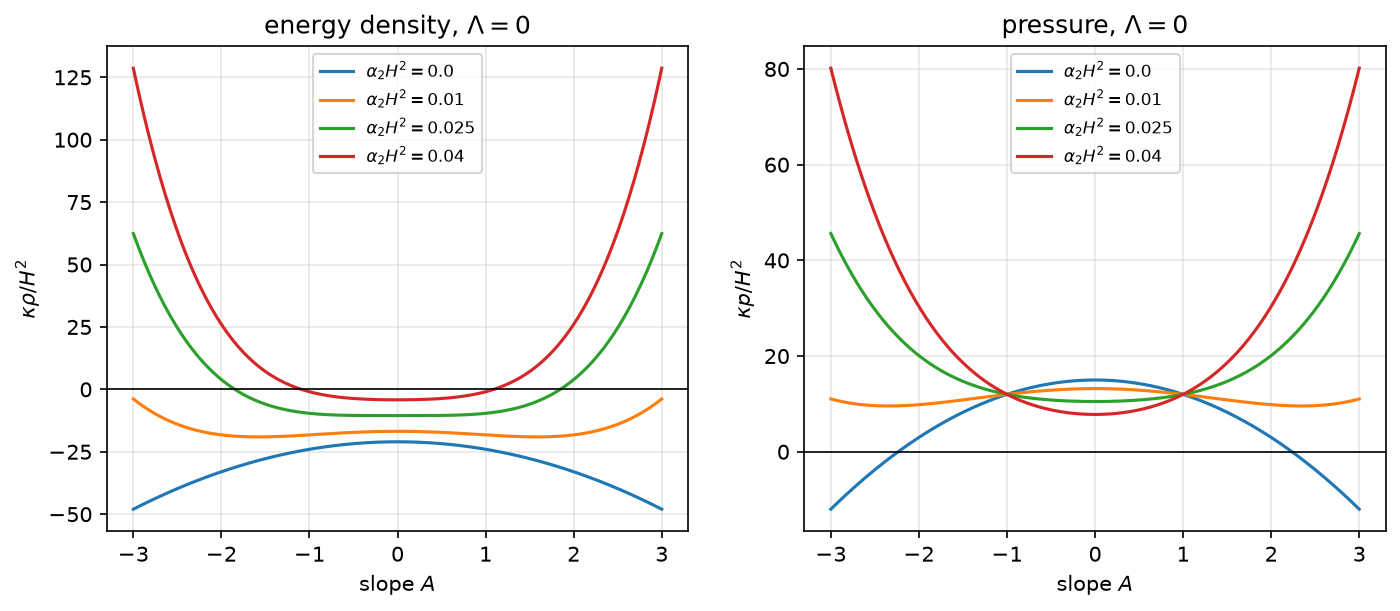

Figure 12b.4 saved as Revision/textbook/figures/12b_4_gauss_bonnet_source.png
PASS Gauss-Bonnet, Lambda = 0, A = 0: kappa rho = (420 alpha2 H^2 - 21) H^2
PASS Gauss-Bonnet, Lambda = 0, A = +1 or -1: kappa p = 12 H^2 for every alpha2


In [9]:
reproduces(sp.expand(sp.diff(kappa_rho, alpha2)
                     - H ** 4 * (36 * A ** 4 + 120 * A ** 2 + 420)) == 0,
           "the alpha2 part of kappa rho is H^4 (36 A^4 + 120 A^2 + 420)",
           LEAD, "gauss_bonnet_rho_alpha2")
reproduces(sp.expand(sp.diff(kappa_p, alpha2)
                     - 12 * H ** 4 * (A ** 4 + 14 * A ** 2 - 15)) == 0,
           "the alpha2 part of kappa p is 12 H^4 (A^4 + 14 A^2 - 15)",
           LEAD, "gauss_bonnet_p_alpha2")
symbols_numeric = (A, Lam, alpha1, alpha2, alpha3)
rho_l = sp.lambdify(symbols_numeric, kappa_rho.subs(H, 1), "numpy")  # any coupling
p_l = sp.lambdify(symbols_numeric, kappa_p.subs(H, 1), "numpy")
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.2))
for a2 in (0.0, 0.01, 0.025, 0.04):
    label = f"$\\alpha_2H^2 = {a2}$"
    left.plot(a_values, rho_l(a_values, 0, 1, a2, 0), label=label)
    right.plot(a_values, p_l(a_values, 0, 1, a2, 0), label=label)
for ax, name in ((left, "\\kappa\\rho/H^2"), (right, "\\kappa p/H^2")):
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.set_xlabel("slope $A$")
    ax.set_ylabel(f"${name}$")
    ax.legend(fontsize=8)
left.set_title("energy density, $\\Lambda = 0$")
right.set_title("pressure, $\\Lambda = 0$")
save_figure(fig, "gauss_bonnet_source",
            "Einstein-Gauss-Bonnet gravity ($\\alpha_1 = 1$, $\\alpha_3 = 0$, "
            "$\\Lambda = 0$): the energy density $\\kappa\\rho$ (left) and the pressure "
            "$\\kappa p$ (right) that the linear member requires, in units of $H^2$, "
            "as functions of the slope $A$, for $\\alpha_2 H^2 = 0$ (Einstein), "
            "$0.01$, $0.025$ and $0.04$. The Gauss-Bonnet term adds "
            "$\\alpha_2 H^4(36A^4 + 120A^2 + 420)$ to $\\kappa\\rho$: for "
            "$\\alpha_2 H^2 = 0.025$ and $0.04$ the energy density is positive at "
            "large $|A|$ without any cosmological constant, while at $A = 0$ it is "
            "$(420\\alpha_2H^2 - 21)H^2$, positive only for $\\alpha_2 H^2 > 1/20$. "
            "All pressure curves meet at $A = \\pm 1$, where $\\kappa p = 12H^2$ for "
            "every $\\alpha_2$; every curve is symmetric under $A \\to -A$.")
rho_gb_0 = sp.expand(kappa_rho.subs({alpha1: 1, alpha3: 0, Lam: 0, A: 0}))
check(sp.expand(rho_gb_0 - (420 * alpha2 * H ** 4 - 21 * H ** 2)) == 0,
      "Gauss-Bonnet, Lambda = 0, A = 0: kappa rho = (420 alpha2 H^2 - 21) H^2")
p_gb_1 = [sp.expand(kappa_p.subs({alpha1: 1, alpha3: 0, Lam: 0, A: s}))
          for s in (1, -1)]
check(p_gb_1 == [12 * H ** 2, 12 * H ** 2],
      "Gauss-Bonnet, Lambda = 0, A = +1 or -1: kappa p = 12 H^2 for every alpha2")

**The null energy condition and the vacuum.** For every coupling the record
factorises

$$\kappa(\rho + p) = -6(A^2 + 1)H^2\,V,\qquad
V = \alpha_1 - 8\alpha_2H^2(A^2 + 5) + \alpha_3H^4(72A^4 + 144A^2 + 360).$$

So the null energy condition $\rho + p \ge 0$ holds exactly where $V \le 0$, and a
vacuum ($\rho = p = 0$) needs $V = 0$ (and then $\Lambda$ chosen so that
$\rho = 0$). The next cell checks the factorisation against the record and draws
the sign of $V$ in the plane of $A$ and $\alpha_2H^2$ (with $\alpha_1 = 1$,
$\alpha_3 = 0$). The boundary $V = 0$ is the curve
$A^2 = (1 - 40\alpha_2H^2)/(8\alpha_2H^2)$, which has real points only for
$0 < \alpha_2H^2 \le 1/40$.

PASS kappa (rho + p) = -6 (A^2 + 1) H^2 V for every coupling
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    linear_member_vacuum_factor
PASS Gauss-Bonnet: V = 1 - 8 alpha2 H^2 (A^2 + 5)
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    einstein_gauss_bonnet_vacuum_linear


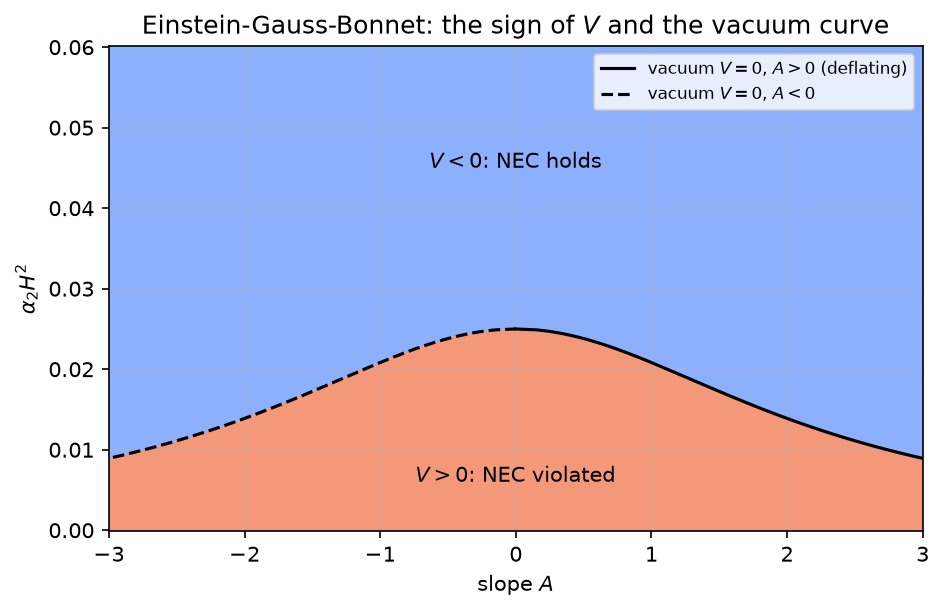

Figure 12b.5 saved as Revision/textbook/figures/12b_5_null_energy_map.png


In [10]:
V = parse(linear_record["vacuumFactor"]["input"])  # the record vacuum factor
reproduces(sp.expand(kappa_rho + kappa_p + 6 * (A ** 2 + 1) * H ** 2 * V) == 0,
           "kappa (rho + p) = -6 (A^2 + 1) H^2 V for every coupling",
           PY, "linear_member_vacuum_factor")
V_gb = sp.expand(V.subs({alpha1: 1, alpha3: 0}))
reproduces(sp.expand(V_gb - (1 - 8 * alpha2 * H ** 2 * (A ** 2 + 5))) == 0,
           "Gauss-Bonnet: V = 1 - 8 alpha2 H^2 (A^2 + 5)",
           PY, "einstein_gauss_bonnet_vacuum_linear")
a_grid, g_grid = np.meshgrid(np.linspace(-3, 3, 241), np.linspace(0.0, 0.06, 241))
V_grid = 1 - 8 * g_grid * (a_grid ** 2 + 5)  # V with H = 1
fig, ax = plt.subplots()
ax.pcolormesh(a_grid, g_grid, np.sign(V_grid), cmap="coolwarm", shading="auto",
              vmin=-2, vmax=2)
g_curve = np.linspace(0.0025, 1 / 40, 200)  # alpha2 H^2 on the vacuum curve
a_curve = np.sqrt((1 - 40 * g_curve) / (8 * g_curve))
ax.plot(a_curve, g_curve, color="black", label="vacuum $V = 0$, $A > 0$ (deflating)")
ax.plot(-a_curve, g_curve, "--", color="black", label="vacuum $V = 0$, $A < 0$")
ax.text(0, 0.006, "$V > 0$: NEC violated", ha="center")
ax.text(0, 0.045, "$V < 0$: NEC holds", ha="center")
ax.set_xlim(-3, 3)
ax.set_xlabel("slope $A$")
ax.set_ylabel("$\\alpha_2 H^2$")
ax.set_title("Einstein-Gauss-Bonnet: the sign of $V$ and the vacuum curve")
ax.legend(fontsize=8, loc="upper right")
save_figure(fig, "null_energy_map",
            "Einstein-Gauss-Bonnet gravity ($\\alpha_1 = 1$, $\\alpha_3 = 0$): the "
            "sign of the factor $V = 1 - 8\\alpha_2H^2(A^2 + 5)$ in the plane of the "
            "slope $A$ (horizontal) and $\\alpha_2 H^2$ (vertical). Where $V > 0$ "
            "(lower region) the required source violates the null energy condition, "
            "$\\rho + p < 0$; where $V < 0$ it satisfies it. On the black curves "
            "$V = 0$, $A^2 = (1 - 40\\alpha_2H^2)/(8\\alpha_2H^2)$, a vacuum is "
            "possible; the solid branch has $A > 0$ (deflating extra times), the "
            "dashed one is its mirror image $A < 0$. Above $\\alpha_2H^2 = 1/40$ "
            "there is no vacuum.")

**The Einstein-Gauss-Bonnet vacuum.** On the curve $V = 0$ we still need $\rho = 0$,
which fixes $\Lambda = -\sum_k \alpha_k E_{(k)}{}^{x_4}{}_{x_4}$ at $a_4' = AH$;
then $p = 0$ follows from $\rho + p \propto V = 0$. The next cell substitutes
$A^2 = (1 - 40\alpha_2H^2)/(8\alpha_2H^2)$ and this $\Lambda$ and checks that
$\rho = p = 0$ for every $\alpha_2$; then it draws the slope $A$ and $\Lambda/H^2$
of the vacuum as functions of $\alpha_2H^2$. At $\alpha_2H^2 = 1/40$ the vacuum
is static ($A = 0$) with $\Lambda = -21H^2 + 420H^2/40 = -10.5H^2$.

Lambda of the vacuum: 720*H**4*alpha2 - 36*H**2 + 3/(16*alpha2)
PASS Gauss-Bonnet vacuum: with V = 0 and Lambda from rho = 0, also p = 0
RESULT vacuum at alpha2 H^2 = 1/40: Lambda/H^2 = -21/2
PASS at alpha2 H^2 = 1/40: A = 0, Lambda = -10.5 H^2


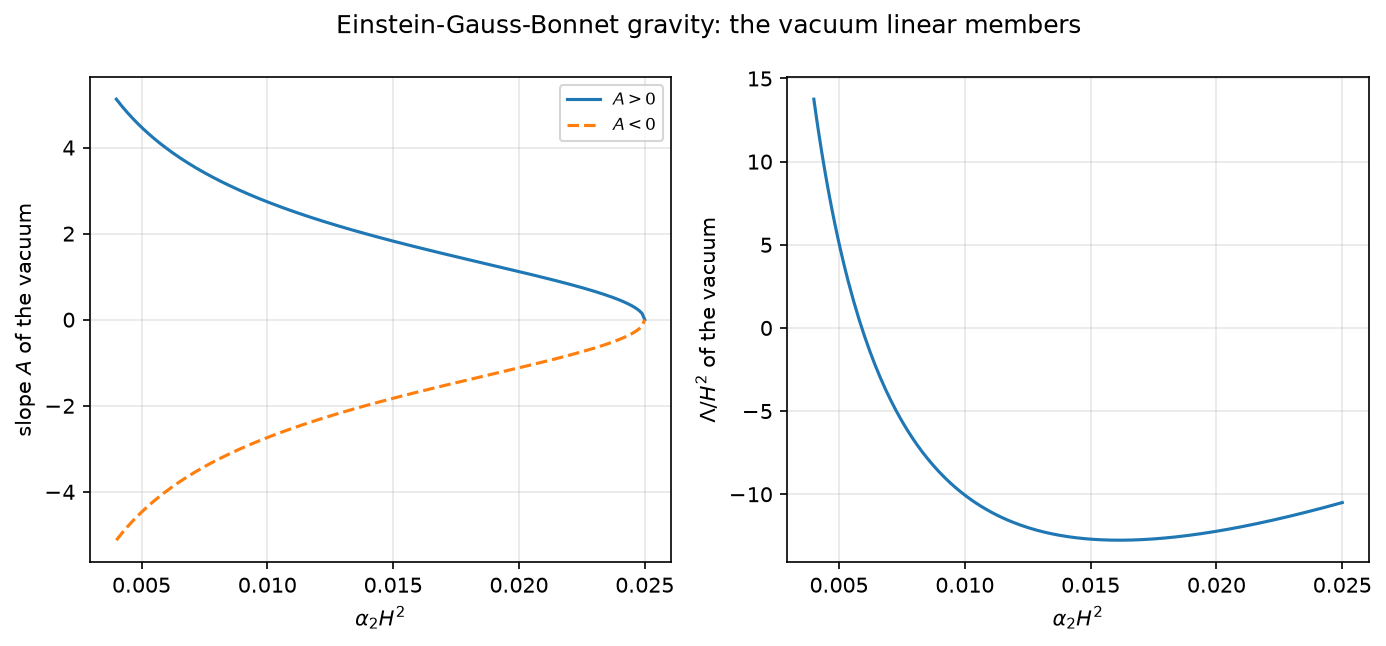

Figure 12b.6 saved as Revision/textbook/figures/12b_6_gauss_bonnet_vacuum.png


In [11]:
A2_vacuum = (1 - 40 * alpha2 * H ** 2) / (8 * alpha2 * H ** 2)  # A^2 on V = 0
GB = {alpha1: 1, alpha3: 0}
rho_gb = sp.expand(kappa_rho.subs(GB))
Lam_vacuum = sp.solve(rho_gb, Lam)[0]  # the Lambda that makes rho = 0
Lam_on_curve = sp.simplify(Lam_vacuum.subs(A ** 2, A2_vacuum))
say(f"Lambda of the vacuum: {Lam_on_curve}")
p_on_curve = sp.simplify((kappa_p.subs(GB).subs(Lam, Lam_vacuum)).subs(A ** 2,
                                                                   A2_vacuum))
check(p_on_curve == 0,
      "Gauss-Bonnet vacuum: with V = 0 and Lambda from rho = 0, also p = 0")
at_edge = Lam_on_curve.subs({alpha2: sp.Rational(1, 40), H: 1})
report("vacuum at alpha2 H^2 = 1/40: Lambda/H^2", at_edge)
check(at_edge == sp.Rational(-21, 2), "at alpha2 H^2 = 1/40: A = 0, Lambda = -10.5 H^2")
lam_vac_f = sp.lambdify(alpha2, Lam_on_curve.subs(H, 1), "numpy")
g_curve = np.linspace(0.004, 1 / 40, 200)
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.2))
left.plot(g_curve, np.sqrt((1 - 40 * g_curve) / (8 * g_curve)), label="$A > 0$")
left.plot(g_curve, -np.sqrt((1 - 40 * g_curve) / (8 * g_curve)), "--",
          label="$A < 0$")
left.set_xlabel("$\\alpha_2 H^2$")
left.set_ylabel("slope $A$ of the vacuum")
left.legend(fontsize=8)
right.plot(g_curve, lam_vac_f(g_curve))
right.set_xlabel("$\\alpha_2 H^2$")
right.set_ylabel("$\\Lambda/H^2$ of the vacuum")
fig.suptitle("Einstein-Gauss-Bonnet gravity: the vacuum linear members")
save_figure(fig, "gauss_bonnet_vacuum",
            "The vacuum solutions of Einstein-Gauss-Bonnet gravity ($\\alpha_1 = 1$, "
            "$\\alpha_3 = 0$) among the linear members, as functions of "
            "$\\alpha_2 H^2$ from $0.004$ to $1/40$: left, the slope $A$ (two "
            "branches $\\pm A$ with $A^2 = (1 - 40\\alpha_2H^2)/(8\\alpha_2H^2)$); "
            "right, the cosmological constant $\\Lambda/H^2$ that makes the energy "
            "density zero. The slope shrinks to $0$ at $\\alpha_2H^2 = 1/40$, where "
            "$\\Lambda = -10.5H^2$; for smaller $\\alpha_2$ the vacuum deflates (or "
            "inflates) the extra times faster.")

**Third order.** With $\alpha_3 \ne 0$ the vacuum condition $V = 0$ is, for a fixed
slope $A$, one straight line in the plane of $\alpha_2H^2$ and $\alpha_3H^4$:

$$\alpha_3H^4 = \frac{8\alpha_2H^2(A^2 + 5) - 1}{72A^4 + 144A^2 + 360}
\qquad(\alpha_1 = 1).$$

The next cell draws these lines for $A = 0, 1, 2, 3$ and checks one point:
for $A = 1$ and $\alpha_2H^2 = 1/48$ the line gives $\alpha_3 = 0$ and indeed
$V = 1 - 8 \cdot \tfrac{1}{48} \cdot 6 = 0$.

vacuum line: alpha3 H^4 = (8*A**2*alpha2 + 40*alpha2 - 1)/(72*(A**4 + 2*A**2 + 5))
PASS A = 1, alpha2 H^2 = 1/48: the vacuum line passes through alpha3 = 0


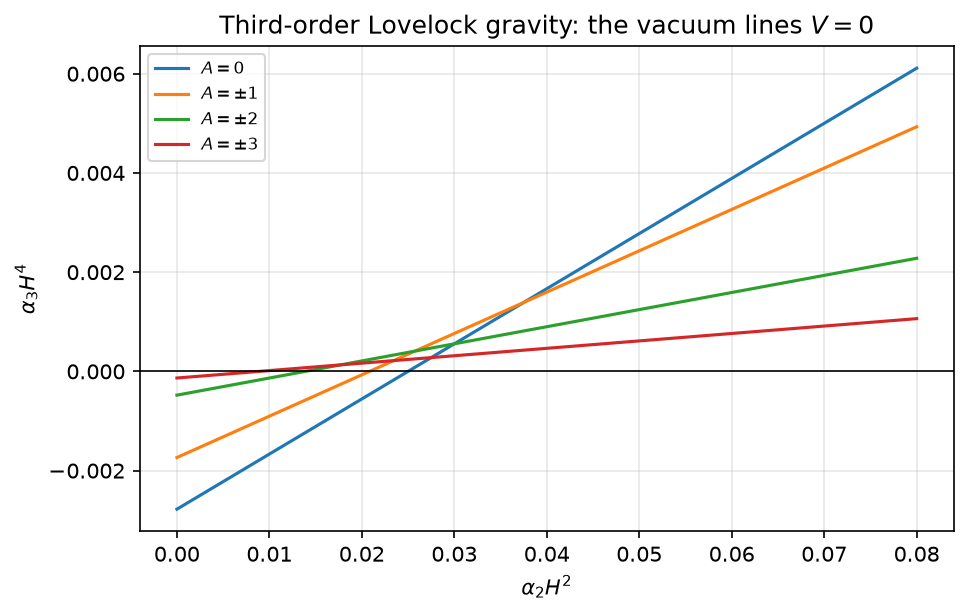

Figure 12b.7 saved as Revision/textbook/figures/12b_7_third_order_vacua.png


In [12]:
V_one = sp.expand(V.subs({alpha1: 1, H: 1}))  # V with alpha1 = 1, H = 1
alpha3_line = sp.solve(V_one, alpha3)[0]  # alpha3 H^4 on the vacuum line
say(f"vacuum line: alpha3 H^4 = {sp.factor(alpha3_line)}")
check(alpha3_line.subs({A: 1, alpha2: sp.Rational(1, 48)}) == 0,
      "A = 1, alpha2 H^2 = 1/48: the vacuum line passes through alpha3 = 0")
line_f = sp.lambdify((A, alpha2), alpha3_line, "numpy")
g_values = np.linspace(0.0, 0.08, 201)
fig, ax = plt.subplots()
for slope in (0, 1, 2, 3):
    label = "$A = 0$" if slope == 0 else f"$A = \\pm{slope}$"
    ax.plot(g_values, line_f(slope, g_values), label=label)
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xlabel("$\\alpha_2 H^2$")
ax.set_ylabel("$\\alpha_3 H^4$")
ax.set_title("Third-order Lovelock gravity: the vacuum lines $V = 0$")
ax.legend(fontsize=8)
save_figure(fig, "third_order_vacua",
            "Lovelock gravity of third order ($\\alpha_1 = 1$): for each slope $A$ "
            "of the linear member the couplings $(\\alpha_2 H^2, \\alpha_3 H^4)$ that "
            "allow a vacuum lie on one straight line, $\\alpha_3 H^4 = "
            "(8\\alpha_2H^2(A^2 + 5) - 1)/(72A^4 + 144A^2 + 360)$, drawn for "
            "$A = 0, 1, 2, 3$ (each line serves $+A$ and $-A$). Where a line crosses "
            "$\\alpha_3 = 0$ it meets the Gauss-Bonnet vacuum; a positive $\\alpha_3$ "
            "allows vacua at larger $\\alpha_2$.")

## 9. A homogeneous condensate of dirac16complex00 as the source

The record proves (checks `condensate_S_constant`,
`condensate_kinetic_tensor_diagonal`) that a condensate $\Phi(x_4)$ of the commuting
field has constant $S = \bar\Phi\Phi$, energy density $\rho = mS + U(S)$ and equal
pressures $p = SU'(S) - U(S)$ (sign convention $\sigma_T = +1$ of the record), and
that, when its off-diagonal conditions hold (see below), it allows only the
linear member. With $U = \tfrac{\lambda}{2}S^2$ we have
$U' = \lambda S$, so $\rho = mS + \tfrac{\lambda}{2}S^2$ and $p = \tfrac{\lambda}{2}S^2$.
Setting them equal to the Einstein values and taking the difference and the sum:

$$\kappa mS = -(36H^2 + 2\Lambda),\qquad 6(A^2 + 1)H^2 = -\kappa S(m + \lambda S).$$

The next cell checks this equivalence with sympy, then solves for $A^2$ in units
$H = \kappa = 1$: $S = -(36 + 2\Lambda)/m$ and
$A^2 = 5 + \Lambda/3 - \lambda S^2/6$. For the two worked examples it also prints
the density $S$ and the effective mass $M = m + \lambda S$ that the condensate
must have.

In [13]:
m, lam, S = sp.symbols("m lam S", real=True)  # mass, coupling lambda, density S
rho_condensate = m * S + lam * S ** 2 / 2  # rho = m S + U, U = (lambda/2) S^2
p_condensate = lam * S ** 2 / 2  # p = S U' - U
condition_rho = sp.expand(kappa * rho_condensate - rho_e)  # = 0
condition_p = sp.expand(kappa * p_condensate - p_e)  # = 0
first = sp.expand(kappa * m * S + 36 * H ** 2 + 2 * Lam)  # kappa m S = -(36 H^2 + 2 L)
second = sp.expand(6 * (A ** 2 + 1) * H ** 2 + kappa * S * (m + lam * S))
reproduces(sp.expand(condition_rho - condition_p - first) == 0
           and sp.expand(condition_rho + condition_p - second) == 0,
           "condensate, Einstein: kappa m S = -(36 H^2 + 2 Lambda) and "
           "6 (A^2 + 1) H^2 = -kappa S (m + lambda S)",
           PY, "condensate_einstein_quadratic_U")
UNIT = {H: 1, kappa: 1}
S_solution = sp.solve(first.subs(UNIT), S)[0]
A2_solution = sp.expand(sp.solve(second.subs(UNIT), A ** 2)[0].subs(S, S_solution))
say(f"S = {S_solution},  A^2 = {A2_solution}")
example_1 = A2_solution.subs({m: 5, lam: 0, Lam: 0})
example_2 = A2_solution.subs({m: -15, lam: sp.Rational(25, 6), Lam: 0})
report("m = 5, lambda = 0, Lambda = 0: A^2", example_1)
report("m = -15, lambda = 25/6, Lambda = 0: A^2", example_2)
check(example_1 == 5 and example_2 == 1, "the two worked examples: A^2 = 5 and A^2 = 1")
effective = []  # the effective mass M = m + lambda S of each example
for mass, coupling in ((5, 0), (-15, sp.Rational(25, 6))):
    S_value = S_solution.subs({m: mass, Lam: 0})  # the density the example needs
    effective.append(mass + coupling * S_value)
    report(f"m = {mass}, lambda = {coupling}: S and M = m + lambda S",
           f"{S_value}, {effective[-1]}")
check(effective == [5, -5], "the examples need M = 5 (S < 0) and M = -5 (S > 0)")

PASS condensate, Einstein: kappa m S = -(36 H^2 + 2 Lambda) and 6 (A^2 + 1) H^2 = -kappa
    S (m + lambda S)
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    condensate_einstein_quadratic_U
S = 2*(-Lam - 18)/m,  A^2 = -2*Lam**2*lam/(3*m**2) - 24*Lam*lam/m**2 + Lam/3 -
    216*lam/m**2 + 5
RESULT m = 5, lambda = 0, Lambda = 0: A^2 = 5
RESULT m = -15, lambda = 25/6, Lambda = 0: A^2 = 1
PASS the two worked examples: A^2 = 5 and A^2 = 1
RESULT m = 5, lambda = 0: S and M = m + lambda S = -36/5, 5
RESULT m = -15, lambda = 25/6: S and M = m + lambda S = 12/5, -5
PASS the examples need M = 5 (S < 0) and M = -5 (S > 0)


The record also lists every off-diagonal kinetic component of the condensate: each
is a multiple of one of 15 three-gamma bilinears
$\bar\Phi\gamma^a\gamma^b\gamma^c\Phi$, and the off-diagonal field equations
$0 = \kappa T^\mu{}_\nu$ require those bilinears to vanish. The next cell counts
the entries (42 ordered pairs $(\mu, \nu)$) and the distinct bilinears (15).

Then it draws $A^2$ as a function of $\lambda$ for $m = 5$ and $m = -15$
($\Lambda = 0$, $H = \kappa = 1$): $A^2 = 5 - 216\lambda/m^2$. A real slope needs
$A^2 \ge 0$, that is $\lambda \le 5m^2/216$. The two worked examples are marked.

RESULT off-diagonal kinetic components of the condensate = 42
RESULT distinct three-gamma bilinears = 15
PASS 42 off-diagonal components, multiples of 15 three-gamma bilinears
     reproduces Revision/field_equations_a4/reports/wolfram-a4-report.json, check
    condensate_offdiagonal_are_three_gamma_bilinears


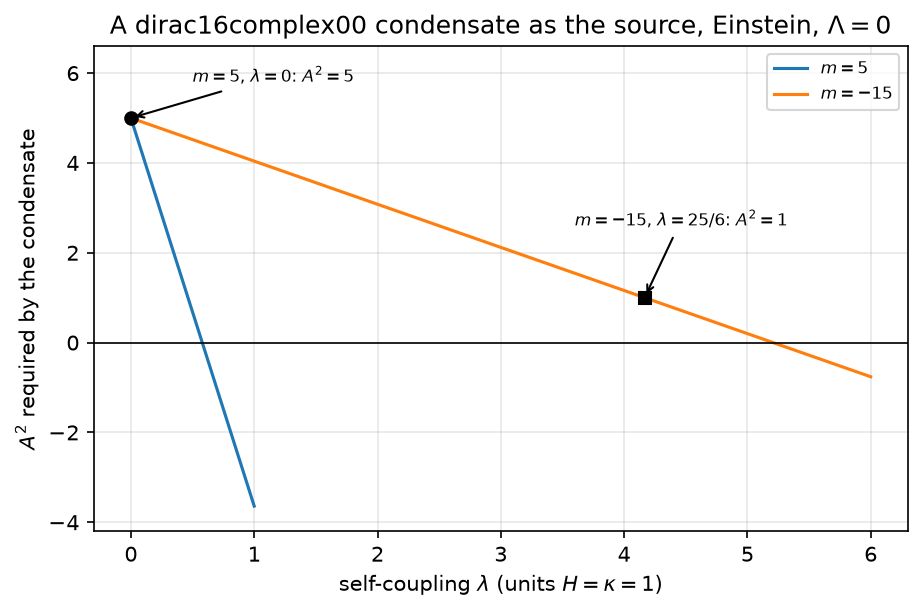

Figure 12b.8 saved as Revision/textbook/figures/12b_8_condensate_slope.png


In [14]:
condensate = record["fields"]["dirac16complex00"]
entries = condensate["offDiagonalKinetic"]
bilinears = sorted({term["bilinear"] for entry in entries for term in entry["terms"]})
report("off-diagonal kinetic components of the condensate", len(entries))
report("distinct three-gamma bilinears", len(bilinears))
reproduces(len(entries) == 42 and len(bilinears) == 15,
           "42 off-diagonal components, multiples of 15 three-gamma bilinears",
           WL, "condensate_offdiagonal_are_three_gamma_bilinears")
a2_f = sp.lambdify((m, lam), A2_solution.subs(Lam, 0), "numpy")
fig, ax = plt.subplots()
for mass, upper in ((5, 1.0), (-15, 6.0)):
    lam_values = np.linspace(0.0, upper, 200)
    ax.plot(lam_values, a2_f(mass, lam_values), label=f"$m = {mass}$")
ax.plot([0], [5], "o", color="black")
ax.plot([25 / 6], [1], "s", color="black")
arrow = {"arrowstyle": "->"}  # a thin arrow from the text to the point
ax.annotate("$m=5$, $\\lambda=0$: $A^2=5$", (0, 5), (0.5, 5.8), fontsize=8,
            arrowprops=arrow)
ax.annotate("$m=-15$, $\\lambda=25/6$: $A^2=1$", (25 / 6, 1), (3.6, 2.6),
            fontsize=8, arrowprops=arrow)
ax.set_ylim(-4.2, 6.6)
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xlabel("self-coupling $\\lambda$ (units $H = \\kappa = 1$)")
ax.set_ylabel("$A^2$ required by the condensate")
ax.set_title("A dirac16complex00 condensate as the source, Einstein, $\\Lambda=0$")
ax.legend(fontsize=8)
save_figure(fig, "condensate_slope",
            "Einstein gravity with $\\Lambda = 0$ and a homogeneous dirac16complex00 "
            "condensate with $U = \\lambda S^2/2$ as the source: the square $A^2$ of "
            "the slope of the linear member that the field equations then require, "
            "$A^2 = 5 - 216\\lambda/m^2$, as a function of the self-coupling "
            "$\\lambda$ for the masses $m = 5$ and $m = -15$ (units "
            "$H = \\kappa = 1$). A real slope needs $A^2 \\ge 0$. The circle and the "
            "square mark the worked examples $A^2 = 5$ and $A^2 = 1$; both signs "
            "$\\pm A$ are allowed.")

**What is established here, and where it is completed.** The two conditions above
are PROVED consequences of the field equations for a condensate source. The
Revision record has exact condensates with all 15 bilinears zero, but it contains
no check that combines one of them with these Einstein conditions. Notebook 12d of
this chapter does that combination: it builds condensates with all 15 bilinears
zero and exactly the values $(M, S) = (5, -36/5)$ and $(-5, 12/5)$ of the two worked
examples, and checks every field equation exactly (a computation of the textbook,
not a Revision record). With $\Lambda = 0$ the required energy density is
$\kappa\rho = -(21 + 3A^2)H^2 < 0$: such a source has negative energy.

## 10. The last check

The last cell checks that the eight figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [15]:
figure_names = ["einstein_source", "source_regions", "phantom_w",
                "gauss_bonnet_source", "null_energy_map", "gauss_bonnet_vacuum",
                "third_order_vacua", "condensate_slope"]
paths = [output_file(f"{FIGURE_FOLDER}/12b_{k}_{name}.png")
         for k, name in enumerate(figure_names, 1)]
check(all(path.is_file() for path in paths), "all eight figure files exist")
all_checks_passed()

PASS all eight figure files exist
ALL 24 CHECKS PASSED (notebook 12b)


## 11. What this notebook showed

- The linear member $a_4 = AHx_4 + a_0$ needs a source with equal pressures
  $p_3 = p_t = p_8 = p$ and constant $\rho$ and $p$, given by the record formulas
  (PROVED).
- $\rho$ and $p$ contain $A$ only as $A^2$: the field equations accept deflating
  extra times ($A > 0$) and inflating ones ($A < 0$) equally; deflation is a choice
  of sign, an initial condition (PROVED).
- Einstein gravity: $\kappa\rho = -(21 + 3A^2)H^2 - \Lambda$,
  $\kappa p = (15 - 3A^2)H^2 + \Lambda$, $\kappa(\rho + p) = -6(1 + A^2)H^2 < 0$;
  $\rho > 0$ is possible only with $\Lambda < -(21 + 3A^2)H^2$ and then $w < -1$
  (PROVED).
- Gauss-Bonnet and third-order couplings: $\kappa(\rho + p) = -6(A^2 + 1)H^2V$; the
  null energy condition holds where $V \le 0$; vacua exist on $V = 0$, for
  Einstein-Gauss-Bonnet gravity only when $0 < \alpha_2 H^2 \le 1/40$ (PROVED).
- A homogeneous dirac16complex00 condensate as the source needs
  $\kappa mS = -(36H^2 + 2\Lambda)$ and $6(A^2 + 1)H^2 = -\kappa S(m + \lambda S)$
  (PROVED); the two worked examples need $(M, S) = (5, -36/5)$ and $(-5, 12/5)$,
  and Notebook 12d builds condensates that meet them exactly.